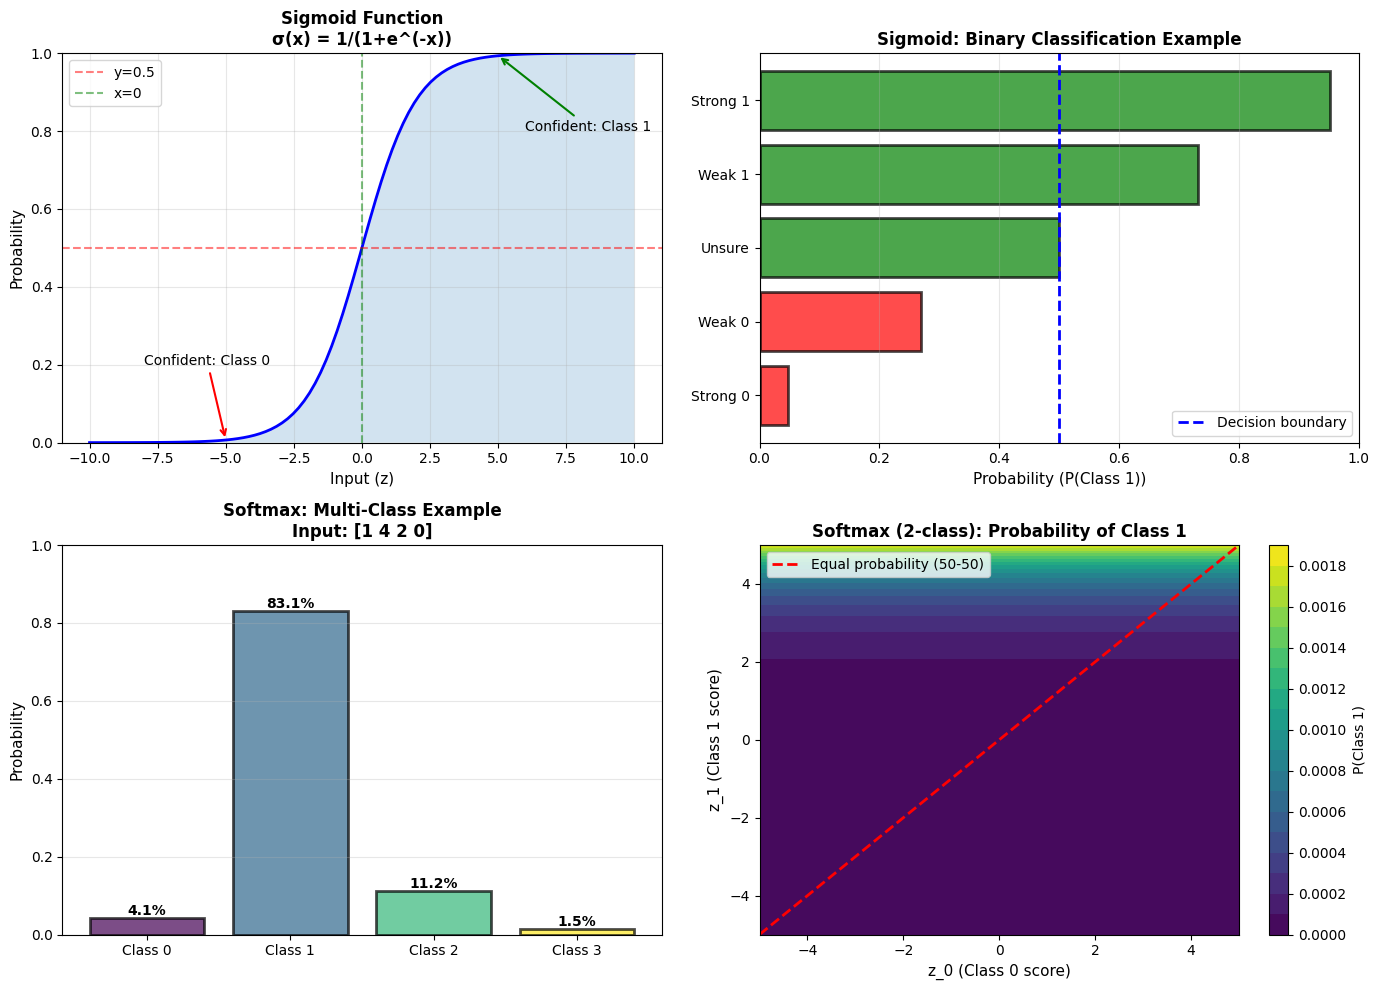

SIGMOID vs SOFTMAX EXAMPLES

1. SIGMOID - Binary Classification
----------------------------------------------------------------------
Score:  -5 → P(Class1)=0.007, P(Class0)=0.993 → Class 0
Score:  -2 → P(Class1)=0.119, P(Class0)=0.881 → Class 0
Score:   0 → P(Class1)=0.500, P(Class0)=0.500 → Class 0
Score:   2 → P(Class1)=0.881, P(Class0)=0.119 → Class 1
Score:   5 → P(Class1)=0.993, P(Class0)=0.007 → Class 1

2. SOFTMAX - Multi-Class Classification
----------------------------------------------------------------------
Scores: [1, 2, 0] → Probabilities: ['0.245', '0.665', '0.090'] → Winner: Class 1
  Sum of probabilities: 1.0000 (should be 1.0)
Scores: [0, 0, 0] → Probabilities: ['0.333', '0.333', '0.333'] → Winner: Class 0
  Sum of probabilities: 1.0000 (should be 1.0)
Scores: [5, 1, 2] → Probabilities: ['0.936', '0.017', '0.047'] → Winner: Class 0
  Sum of probabilities: 1.0000 (should be 1.0)
Scores: [-2, 3, 1] → Probabilities: ['0.006', '0.876', '0.118'] → Winner: Class 1
  Sum o

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ========== SIGMOID ==========
def sigmoid(x):
    """σ(x) = 1 / (1 + e^(-x))"""
    return 1 / (1 + np.exp(-x))

# ========== SOFTMAX ==========
def softmax(x):
    """σ(x_i) = e^(x_i) / Σ e^(x_j)"""
    exp_x = np.exp(x - np.max(x))  # Subtract max for numerical stability
    return exp_x / np.sum(exp_x)

# ========== VISUALIZATION ==========
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Sigmoid Function
x = np.linspace(-10, 10, 100)
y_sigmoid = sigmoid(x)

axes[0, 0].plot(x, y_sigmoid, 'b-', linewidth=2)
axes[0, 0].axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='y=0.5')
axes[0, 0].axvline(x=0, color='g', linestyle='--', alpha=0.5, label='x=0')
axes[0, 0].fill_between(x, 0, y_sigmoid, alpha=0.2)
axes[0, 0].set_xlabel('Input (z)', fontsize=11)
axes[0, 0].set_ylabel('Probability', fontsize=11)
axes[0, 0].set_title('Sigmoid Function\nσ(x) = 1/(1+e^(-x))', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1])

# Add annotations
axes[0, 0].annotate('Confident: Class 0', xy=(-5, sigmoid(-5)), xytext=(-8, 0.2),
                   arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
axes[0, 0].annotate('Confident: Class 1', xy=(5, sigmoid(5)), xytext=(6, 0.8),
                   arrowprops=dict(arrowstyle='->', color='green', lw=1.5))

# Plot 2: Sigmoid Binary Classification Example
z_examples = np.array([-3, -1, 0, 1, 3])
probs = sigmoid(z_examples)
classes = ['Strong 0', 'Weak 0', 'Unsure', 'Weak 1', 'Strong 1']

colors = ['red' if p < 0.5 else 'green' for p in probs]
axes[0, 1].barh(classes, probs, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0, 1].axvline(x=0.5, color='blue', linestyle='--', linewidth=2, label='Decision boundary')
axes[0, 1].set_xlabel('Probability (P(Class 1))', fontsize=11)
axes[0, 1].set_title('Sigmoid: Binary Classification Example', fontsize=12, fontweight='bold')
axes[0, 1].set_xlim([0, 1])
axes[0, 1].grid(True, alpha=0.3, axis='x')
axes[0, 1].legend()

# Plot 3: Softmax Example - Bar Chart
z_multi = np.array([1, 4, 2, 0])
probs_softmax = softmax(z_multi)
class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3']

colors_softmax = plt.cm.viridis(np.linspace(0, 1, len(class_names)))
bars = axes[1, 0].bar(class_names, probs_softmax, color=colors_softmax, alpha=0.7, 
                      edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Probability', fontsize=11)
axes[1, 0].set_title(f'Softmax: Multi-Class Example\nInput: {z_multi}', 
                     fontsize=12, fontweight='bold')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, prob in zip(bars, probs_softmax):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{prob:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 4: Softmax Heatmap - Show how probabilities change with input
z0_range = np.linspace(-5, 5, 50)
z1_range = np.linspace(-5, 5, 50)
Z0, Z1 = np.meshgrid(z0_range, z1_range)

# For 2-class softmax, prob of class 1
probs_2d = softmax(np.stack([Z0, Z1], axis=-1))[:, :, 1]

im = axes[1, 1].contourf(Z0, Z1, probs_2d, levels=20, cmap='viridis')
axes[1, 1].set_xlabel('z_0 (Class 0 score)', fontsize=11)
axes[1, 1].set_ylabel('z_1 (Class 1 score)', fontsize=11)
axes[1, 1].set_title('Softmax (2-class): Probability of Class 1', fontsize=12, fontweight='bold')
cbar = plt.colorbar(im, ax=axes[1, 1])
cbar.set_label('P(Class 1)', fontsize=10)

# Add diagonal line where probabilities are equal
x_diag = np.linspace(-5, 5, 100)
axes[1, 1].plot(x_diag, x_diag, 'r--', linewidth=2, label='Equal probability (50-50)')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('sigmoid_vs_softmax.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== EXAMPLES ==========
print("="*70)
print("SIGMOID vs SOFTMAX EXAMPLES")
print("="*70)

print("\n1. SIGMOID - Binary Classification")
print("-" * 70)
test_scores = [-5, -2, 0, 2, 5]
for score in test_scores:
    prob_class_1 = sigmoid(score)
    prob_class_0 = 1 - prob_class_1
    prediction = "Class 1" if prob_class_1 > 0.5 else "Class 0"
    print(f"Score: {score:3d} → P(Class1)={prob_class_1:.3f}, P(Class0)={prob_class_0:.3f} → {prediction}")

print("\n2. SOFTMAX - Multi-Class Classification")
print("-" * 70)
test_vectors = [
    [1, 2, 0],
    [0, 0, 0],
    [5, 1, 2],
    [-2, 3, 1]
]
for vec in test_vectors:
    probs = softmax(np.array(vec))
    winner = np.argmax(probs)
    print(f"Scores: {vec} → Probabilities: {[f'{p:.3f}' for p in probs]} → Winner: Class {winner}")
    print(f"  Sum of probabilities: {np.sum(probs):.4f} (should be 1.0)")

print("\n3. MULTI-LABEL - Using Sigmoid for Each Tag")
print("-" * 70)
tag_scores = {'animal': 2.5, 'outdoor': 1.2, 'sunset': 3.1, 'person': -1.5}
print("Tag Probabilities (independent sigmoids):")
for tag, score in tag_scores.items():
    prob = sigmoid(score)
    has_tag = "YES" if prob > 0.5 else "NO"
    print(f"  {tag:10s}: score={score:5.1f} → P={prob:.3f} → {has_tag}")

probs_list = [sigmoid(score) for score in tag_scores.values()]
print(f"\nSum of probabilities: {np.sum(probs_list):.3f} (no constraint!)")
print("(This is OK for multi-label - tags are independent)")